# Big Data Infrastructure

## U-Bahn und Immobilie: Wie beeinflusst die Nähe zur U-Bahn-Station den Mietpreis in Wien?

Michael Lucuta, Jakob Hügelsberger (Gruppe 5)

In [ ]:
# Abhängigkeiten installieren (nur nötig beim ersten Ausführen)
!pip install pymongo folium

In [2]:
import os
import json
from pprint import pprint
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import seaborn as sns
from scipy import stats
from pymongo import MongoClient, UpdateOne

# MongoDB-Verbindung
host = os.environ.get("MONGO_HOST", "localhost")
port = int(os.environ.get("MONGO_PORT", 27017))
user = os.environ.get("MONGO_USER", "admin")
password = os.environ.get("MONGO_PASSWORD", "BigDataMongo2026!")

client = MongoClient(host=host, port=port, username=user, password=password, authSource="admin")
db = client["bigdata"]

col_flats = db["willhaben_mietwohnungen"]
col_stations = db["ubahn_stations"]

print(f"MongoDB-Version: {client.server_info()['version']}")
print(f"Mietwohnungen:   {col_flats.count_documents({})} Dokumente")
print(f"U-Bahn-Stationen: {col_stations.count_documents({})} Dokumente")

MongoDB-Version: 8.2.6
Mietwohnungen:   995 Dokumente
U-Bahn-Stationen: 98 Dokumente


---
# 1. Architektur und Infrastruktur

Das Projekt läuft auf einer **Azure VM** mit **Docker**. Die gesamte Infrastruktur wird über `docker-compose` orchestriert und via **GitHub Actions** automatisch deployed.

### Komponenten:
- **MongoDB** — NoSQL-Datenbank, Collections für Mietwohnungen und U-Bahn-Stationen (Anzahl siehe oben)
- **Mongo Express** — Web-UI zur Dateninspektion
- **Scraper-Container** — Python-Skripte für Datenakquise (Mietwohnungen von Willhaben + Stationsdaten von Wiener Linien, genauere Infos zu den Daten im nächsten Kapitel), läuft bei jedem Deploy (= Push auf GitHub)
- **Jupyter Notebook** — Analyse und Dokumentation
- **GitHub Actions** — CI/CD-Pipeline: Build → Push zu GHCR → Deploy auf Azure VM via SSH

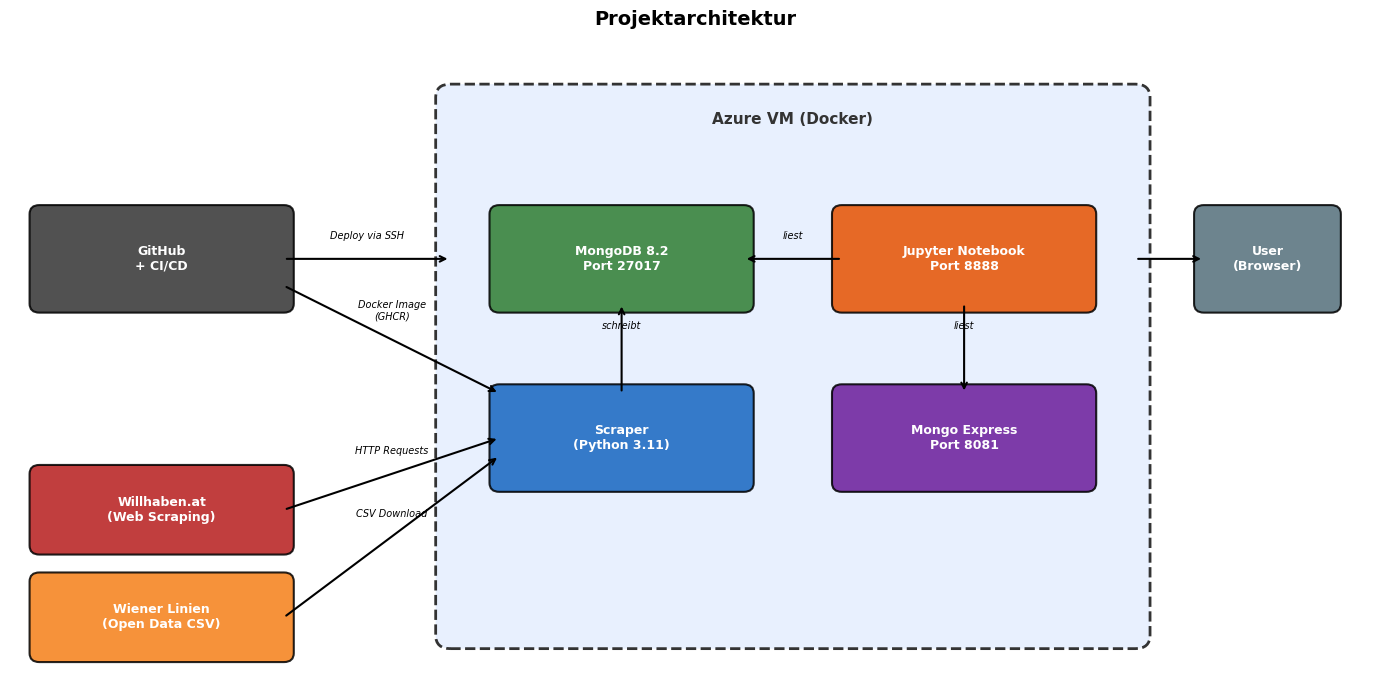

In [ ]:
# Architektur-Diagramm
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis("off")

def draw_box(ax, x, y, w, h, label, color="#4A90D9", fontsize=9):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                         facecolor=color, edgecolor="black", linewidth=1.5, alpha=0.85)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, label, ha="center", va="center",
            fontsize=fontsize, fontweight="bold", color="white")

def draw_arrow(ax, x1, y1, x2, y2, label=""):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.5))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my + 0.2, label, ha="center", va="bottom", fontsize=7, fontstyle="italic")

# Azure VM box (large container)
vm_box = FancyBboxPatch((4.5, 0.5), 7, 6, boxstyle="round,pad=0.15",
                        facecolor="#E8F0FE", edgecolor="#333", linewidth=2, linestyle="--")
ax.add_patch(vm_box)
ax.text(8, 6.2, "Azure VM (Docker)", ha="center", fontsize=11, fontweight="bold", color="#333")

# Docker containers inside VM
draw_box(ax, 5, 4.2, 2.5, 1.0, "MongoDB 8.2\nPort 27017", "#2E7D32")
draw_box(ax, 8.5, 4.2, 2.5, 1.0, "Jupyter Notebook\nPort 8888", "#E65100")
draw_box(ax, 5, 2.2, 2.5, 1.0, "Scraper\n(Python 3.11)", "#1565C0")
draw_box(ax, 8.5, 2.2, 2.5, 1.0, "Mongo Express\nPort 8081", "#6A1B9A")

# Arrows inside VM
draw_arrow(ax, 6.25, 3.2, 6.25, 4.2, "schreibt")  # Scraper -> MongoDB
draw_arrow(ax, 7.5, 4.4, 8.5, 2.9, "liest")       # MongoDB -> Mongo Express
draw_arrow(ax, 8.5, 4.7, 7.5, 4.7, "liest")         # Jupyter -> MongoDB

# External: GitHub
draw_box(ax, 0.3, 4.2, 2.5, 1.0, "GitHub\n+ CI/CD", "#333333")
draw_arrow(ax, 2.8, 4.7, 4.5, 4.7, "Deploy via SSH")
draw_arrow(ax, 2.8, 4.4, 5, 3.2, "Docker Image\n(GHCR)")

# External: Data Sources
draw_box(ax, 0.3, 1.5, 2.5, 0.8, "Willhaben.at\n(Web Scraping)", "#B71C1C")
draw_box(ax, 0.3, 0.3, 2.5, 0.8, "Wiener Linien\n(Open Data CSV)", "#F57F17")
draw_arrow(ax, 2.8, 1.9, 5, 2.7, "HTTP Requests")
draw_arrow(ax, 2.8, 0.7, 5, 2.5, "CSV Download")

# External: Users
draw_box(ax, 12.2, 4.2, 1.3, 1.0, "User\n(Browser)", "#546E7A")
draw_arrow(ax, 11.5, 4.7, 12.2, 4.7)

plt.title("Projektarchitektur", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

### 1.1 Verwendete Komponenten und Versionen

| Komponente | Version | Beschreibung |
|---|---|---|
| MongoDB | 8.2.6 | NoSQL-Datenbank |
| Python | 3.11 | Scraper und Analyse |
| pymongo | >= 4.6 | MongoDB-Treiber für Python |
| requests | >= 2.31 | HTTP-Client für Web Scraping |
| BeautifulSoup4 | >= 4.12 | HTML/JSON-Parsing |
| pandas | >= 2.0 | Datenanalyse |
| matplotlib / seaborn | — | Visualisierung |
| folium | — | Interaktive Karten |
| scipy | — | Statistische Tests |
| jupyter/scipy-notebook | latest | Jupyter-Umgebung |
| Mongo Express | latest | Web-UI für MongoDB |
| Docker / Docker Compose | — | Container-Orchestrierung |
| GitHub Actions | — | CI/CD-Pipeline |

### 1.2 Multi-User-Setup

- **Git:** gemeinsames Repo auf GitHub (`github.com/Luatius/BigData-Project`)
- **MongoDB:** läuft auf der Azure VM mit Public IP, Zugriff über Mongo Express (Port 8081) und Jupyter (Port 8888)
- **CI/CD:** jeder Push auf `main` löst automatisches Deployment aus — Build des Scraper-Images, Push zu GHCR, Deploy auf die VM via SSH
- **Jupyter:** Notebooks liegen im Git-Repository

---
# 2. Datenquellen

Das Projekt verwendet zwei Datenquellen, die über Koordinaten miteinander verknüpft werden:

### 2.1 Willhaben Mietwohnungen (Web Scraping)

**Quelle:** https://www.willhaben.at/iad/immobilien/mietwohnungen/wien/

Das Python-Skript `run_scraper.py` durchsucht die Willhaben-Suchergebnisse für Mietwohnungen in Wien. Pro Durchlauf werden bis zu 1000 Seiten mit  25 Inseraten gescrapt. Um nicht gesperrt zu werden, wird ein 5-Sekunden Delay zwischen Rquests abgewartet (hoffentlich ausreichend). Besonderer Fokus im Scraper liegt auf dem Vermeiden von Duplikaten (bereits gescrapte Wohnungen sollen nicht erneut in die DB kommen).

**Extrahierte Felder:** `willhaben_id`, `title`, `price` (EUR/Monat), `area_m2`, `rooms`, `location`, `postcode`, `district` (1–23), `latitude/longitude`, `property_type`, `published`, `scraped_at`

Die Koordinaten werden als **GeoJSON Point** gespeichert, was MongoDB-Geospatial-Abfragen ermöglicht (Doku: https://www.mongodb.com/docs/manual/geospatial-queries/).

### 2.2 Wiener Linien U-Bahn-Stationen (Open Data)

**Quelle:** https://www.data.gv.at/home?locale=de (die genauen CSV's sind in `fetch_ubahn_stations.py` ersichtlich)

Das Skript `fetch_ubahn_stations.py` lädt drei CSV-Dateien und verknüpft sie:

1. **Haltestellen** (wienerlinien-ogd-haltestellen.csv) — Stationsnamen + Koordinaten
2. **Linien** (wienerlinien-ogd-linien.csv) — Linienbezeichnung + Verkehrsmittel-Typ
3. **Steige** (wienerlinien-ogd-steige.csv) — Join-Tabelle: verknüpft Stationen mit Linien

Durch Filterung auf `VERKEHRSMITTEL == "ptMetro"` werden nur U-Bahn-Stationen extrahiert. Das Ergebnis: 98 Stationen auf den Linien U1, U2, U3, U4 und U6.

In [4]:
# Beispiel-Dokument: Mietwohnung
sample_flat = col_flats.find_one({}, {"_id": 0})
print("Beispiel: Mietwohnung")
for k, v in sample_flat.items():
    print(f"  {k}: {v}")

print()

# Beispiel-Dokument: U-Bahn-Station
sample_station = col_stations.find_one({}, {"_id": 0})
print("Beispiel: U-Bahn-Station")
for k, v in sample_station.items():
    print(f"  {k}: {v}")

Beispiel: Mietwohnung
  willhaben_id: 849376960
  area_m2: 188.0
  district: 1
  geo: {'type': 'Point', 'coordinates': [16.37227226, 48.20210735]}
  latitude: 48.20210735
  location: Wien, 01. Bezirk, Innere Stadt
  longitude: 16.37227226
  postcode: 1010
  price: 6507.01
  price_raw: 6507.01
  property_type: Wohnung
  published: 2026-04-03T10:30:00Z
  rooms: 3.0
  scraped_at: 2026-04-03 08:48:03.398000
  title: ANNAGASSE | außergewöhnliche 3-Zimmer-DG-Maisonette mit Terrasse in historischem Innenstadt-Palais | extraordinary 3-room-rooftop-duplex with terrace in historic downtown palais
  dist_to_ubahn_m: 277.6994885035508
  distance_band: 200-400m
  nearest_station: Karlsplatz
  price_per_m2: 34.61175531914894

Beispiel: U-Bahn-Station
  station_name: KendlerstraÃe
  lines: ['U3']
  latitude: 48.2047093
  longitude: 16.3090846
  geo: {'type': 'Point', 'coordinates': [16.3090846, 48.2047093]}
  haltestellen_id: 1085621712
  fetched_at: 2026-04-03 08:34:57.740000


**Anmerkung:** Die obige Wohnungen können über willhaben direkt im Suchfel mit dem "title" gesucht werden und die Daten auf Authentizität überprüft werden. Wenn man die Koordinaten aus der DB mittels Google Maps sucht, findet man zudem auch genau den Bereich, der auf willhaben eingezeichnet wird.

In [5]:
# Metadaten und Vollständigkeit
total_flats = col_flats.count_documents({})
with_price = col_flats.count_documents({"price": {"$ne": None}})
with_coords = col_flats.count_documents({"geo": {"$exists": True}})
with_area = col_flats.count_documents({"area_m2": {"$ne": None}})

print(f"Mietwohnungen gesamt:    {total_flats}")
print(f"  mit Preis:             {with_price} ({with_price/total_flats*100:.0f}%)")
print(f"  mit Koordinaten:       {with_coords} ({with_coords/total_flats*100:.0f}%)")
print(f"  mit Fläche (m²):       {with_area} ({with_area/total_flats*100:.0f}%)")
print(f"\nU-Bahn-Stationen:        {col_stations.count_documents({})}")

# Linien-Übersicht
lines = col_stations.distinct("lines")
flat_lines = sorted(set(l for sublist in col_stations.find({}, {"lines": 1, "_id": 0}) for l in sublist["lines"]))
print(f"U-Bahn-Linien:           {flat_lines}")

Mietwohnungen gesamt:    995
  mit Preis:             990 (99%)
  mit Koordinaten:       994 (100%)
  mit Fläche (m²):       962 (97%)

U-Bahn-Stationen:        98
U-Bahn-Linien:           ['U1', 'U2', 'U3', 'U4', 'U6']


---
# 3. Datenspeicherung: Warum MongoDB?

Für dieses Projekt wurde **MongoDB** als Datenbank gewählt. Die Entscheidung basiert auf folgenden Argumenten (neben dem, das NoSQL in der Spezifikation vorgegeben war):

1. **Schema-Flexibilität:** Willhaben-Inserate haben unterschiedliche Felder.

2. **JSON-native:** Die gescrapten Daten liegen als JSON vor (Willhaben's `__NEXT_DATA__`). Diese können direkt als MongoDB-Dokumente gespeichert werden.

3. **Skalierbarkeit:** MongoDB unterstützt Sharding und Replikation. Auch wenn unser Datensatz klein ist, wäre die gleiche Architektur für Millionen von Inseraten einsetzbar. Interessant für den Big Data-Aspekt.

In [6]:
# 3.1 Datenbank-Kommunikation: Indizes anzeigen
print("=== Indizes: willhaben_mietwohnungen ===")
for name, info in col_flats.index_information().items():
    print(f"  {name}: {info['key']}")

print("\n=== Indizes: ubahn_stations ===")
for name, info in col_stations.index_information().items():
    print(f"  {name}: {info['key']}")

=== Indizes: willhaben_mietwohnungen ===
  _id_: [('_id', 1)]
  geo_2dsphere: [('geo', '2dsphere')]
  district_1: [('district', 1)]

=== Indizes: ubahn_stations ===
  _id_: [('_id', 1)]
  geo_2dsphere: [('geo', '2dsphere')]


---
# 4. Datenbereinigung und erste Statistiken

Bevor Analysen durchgeführt werden können, müssen ein paar Dinge bereinigt und überprüft werden, zusätzlich wird eine erste Berechnung für weitere Bereinigung durchgeführt:
- Inserate ohne Preis, Fläche oder Koordinaten entfernen (sind Grundlage für die Frage)
- Offensichtliche Ausreißer filtern (z.B. Stellplätze als „Wohnung")
- Preis pro m² berechnen

In [ ]:
# Daten aus MongoDB laden
df_flats = pd.DataFrame(list(col_flats.find()))
df_stations = pd.DataFrame(list(col_stations.find()))

print(f"Rohdaten: {len(df_flats)} Mietwohnungen, {len(df_stations)} U-Bahn-Stationen")

# Bereinigung
df = df_flats.copy()
before = len(df)

# Nur Einträge mit Preis, Fläche und Koordinaten
df = df.dropna(subset=["price", "area_m2", "latitude", "longitude"])

# Ausreißer entfernen
df = df[(df["price"] >= 200) & (df["price"] <= 10000)]  
df = df[(df["area_m2"] >= 15) & (df["area_m2"] <= 500)]

# Preis pro m² berechnen
df["price_per_m2"] = df["price"] / df["area_m2"]

# Extreme Preis/m²-Werte entfernen
df = df[(df["price_per_m2"] >= 5) & (df["price_per_m2"] <= 50)]

after = len(df)
print(f"Nach Bereinigung: {after} Mietwohnungen ({before - after} entfernt)")
print(f"\nPreis pro m² — Bereich: {df['price_per_m2'].min():.1f} bis {df['price_per_m2'].max():.1f} EUR")

Rohdaten: 995 Mietwohnungen, 98 U-Bahn-Stationen
Nach Bereinigung: 932 Mietwohnungen (63 entfernt)

Preis pro m² — Bereich: 5.7 bis 49.9 EUR


In [ ]:
print("=== Deskriptive Statistik = einfache Darstellung zum Übersicht-bekommen ===\n")
print(df[["price", "area_m2", "rooms", "price_per_m2"]].describe().round(2).to_string())

print("\n\n=== Durchschnittlicher Mietpreis pro Bezirk ===\n")
district_stats = df.groupby("district").agg(
    anzahl=("price", "count"),
    avg_preis=("price", "mean"),
    avg_preis_m2=("price_per_m2", "mean"),
    avg_flaeche=("area_m2", "mean")
).round(1)
print(district_stats.to_string())

=== Deskriptive Statistik ===

         price  area_m2   rooms  price_per_m2
count   932.00   932.00  932.00        932.00
mean   1690.90    74.56    2.47         23.22
std     987.73    39.42    1.07          6.62
min     300.00    15.00    0.00          5.71
25%     999.99    46.00    2.00         18.84
50%    1389.02    63.00    2.00         21.86
75%    1995.00    91.00    3.00         26.59
max    8995.00   349.00    6.00         49.92


=== Durchschnittlicher Mietpreis pro Bezirk ===

          anzahl  avg_preis  avg_preis_m2  avg_flaeche
district                                              
1.0           65     3146.3          27.2        118.7
2.0           39     1933.8          26.2         74.0
3.0           40     1795.4          22.9         82.2
4.0           19     2435.5          23.6        107.8
5.0           36     1388.0          21.7         66.7
6.0           31     2302.9          24.2        100.2
7.0           16     1660.9          20.4         85.0
8.0      

---
# 5. Entfernungsberechnung: Nächste U-Bahn-Station

Für jede Wohnung wird die Entfernung zur nächstgelegenen U-Bahn-Station berechnet. Dafür wird die Haversine-Formel (Doku: https://www.kompf.de/gps/distcalc.html) verwendet, die den kürzesten Abstand zwischen zwei Punkten auf der Erdkugel berechnet.

Anschließend werden die Wohnungen in Entfernungskategorien eingeteilt:
- `<200m`, `200–400m`, `400–700m`, `700–1000m`, `>1000m`

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    """Berechnet die Entfernung zwischen zwei Koordinaten in Metern (Haversine-Formel)."""
    R = 6_371_000 
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

station_lats = df_stations["latitude"].values
station_lons = df_stations["longitude"].values
station_names = df_stations["station_name"].values

min_distances = []
nearest_stations = []

for _, flat in df.iterrows():
    dists = haversine(flat["latitude"], flat["longitude"], station_lats, station_lons)
    min_idx = np.argmin(dists)
    min_distances.append(dists[min_idx])
    nearest_stations.append(station_names[min_idx])

df["dist_to_ubahn_m"] = min_distances
df["nearest_station"] = nearest_stations

def distance_band(d):
    if d < 200: return "<200m"
    elif d < 400: return "200-400m"
    elif d < 700: return "400-700m"
    elif d < 1000: return "700-1000m"
    else: return ">1000m"

df["distance_band"] = df["dist_to_ubahn_m"].apply(distance_band)

print("=== Verteilung nach Entfernungskategorie ===\n")
band_order = ["<200m", "200-400m", "400-700m", "700-1000m", ">1000m"]
counts = df["distance_band"].value_counts().reindex(band_order)
for band, count in counts.items():
    print(f"  {band:>10s}: {count:4d} Wohnungen")

print(f"\nDurchschnittliche Entfernung: {df['dist_to_ubahn_m'].mean():.0f}m")
print(f"Median-Entfernung:           {df['dist_to_ubahn_m'].median():.0f}m")

=== Verteilung nach Entfernungskategorie ===

       <200m:  125 Wohnungen
    200-400m:  269 Wohnungen
    400-700m:  236 Wohnungen
   700-1000m:   68 Wohnungen
      >1000m:  234 Wohnungen

Durchschnittliche Entfernung: 849m
Median-Entfernung:           486m


Die berechneten Felder (`dist_to_ubahn_m`, `nearest_station`, `distance_band`, `price_per_m2`) werden nun zurück in MongoDB geschrieben. Damit liegen sie persistent in den Dokumenten. Das ist zudem auch Grundlage für MapReduce.

In [ ]:
operations = []
for _, row in df.iterrows():
    operations.append(UpdateOne(
        {"_id": row["_id"]},
        {"$set": {
            "dist_to_ubahn_m": row["dist_to_ubahn_m"],
            "nearest_station": row["nearest_station"],
            "distance_band": row["distance_band"],
            "price_per_m2": row["price_per_m2"]
        }}
    ))

if operations:
    result = col_flats.bulk_write(operations)
    print(f"{result.modified_count} Dokumente in MongoDB aktualisiert (distance_band, price_per_m2)")

0 Dokumente in MongoDB aktualisiert (distance_band, price_per_m2)


---
# 6. MapReduce: Durchschnittlicher Preis/m² nach Entfernungskategorie

**MapReduce** ist ein Verarbeitungsmodell für große Datenmengen, das aus zwei Phasen besteht:

1. **Map-Phase:** Jedes Dokument wird auf ein Key-Value-Pair abgebildet. In unserem Fall:
   - Key: Entfernungsband (z.B. `"200-400m"`)
   - Value: `{summe: preis_pro_m2, anzahl: 1}`

2. **Reduce-Phase:** Alle Werte mit dem gleichen Schlüssel werden aggregiert. Die Reduce-Funktion summiert die Preise und Anzahlen pro Entfernungsband.

Aus Summe und Anzahl wird dann der Durchschnitt berechnet.

Der entscheidende Vorteil: Beide Phasen sind parallelisierbar. In einem verteilten System (z.B. Hadoop, MongoDB mit Sharding) kann die Map-Phase auf jedem Knoten lokal laufen, die Ergebnisse werden dann per Reduce zusammengeführt.

In [ ]:
from collections import defaultdict

def map_function(document):
    """Map: Emittiert (distance_band, {sum: price_per_m2, count: 1}) pro Dokument."""
    if document.get("distance_band") and document.get("price_per_m2"):
        yield document["distance_band"], {"sum": document["price_per_m2"], "count": 1}

def reduce_function(key, values):
    """Reduce: Summiert alle Werte pro Schlüssel."""
    result = {"sum": 0, "count": 0}
    for v in values:
        result["sum"] += v["sum"]
        result["count"] += v["count"]
    return result

def finalize(key, reduced):
    """Finalize: Berechnet den Durchschnitt aus Summe und Anzahl."""
    reduced["avg_price_per_m2"] = reduced["sum"] / reduced["count"]
    return reduced

# MAP-Phase: Alle Dokumente durchgehen, Key-Value-Paare emittieren
intermediate = defaultdict(list)
for doc in col_flats.find({"distance_band": {"$exists": True}, "price_per_m2": {"$exists": True}}):
    for key, value in map_function(doc):
        intermediate[key].append(value)

print("=== Map-Phase: Emittierte Schlüssel ===")
for key in sorted(intermediate.keys()):
    print(f"  {key}: {len(intermediate[key])} Werte emittiert")

# REDUCE-Phase: Pro Schlüssel aggregieren
reduced = {}
for key, values in intermediate.items():
    reduced[key] = reduce_function(key, values)

# FINALIZE: Durchschnitt berechnen
results_python = {}
for key, value in reduced.items():
    results_python[key] = finalize(key, value)

print("\n=== MapReduce-Ergebnis (Python) ===")
print(f"\n{'Entfernung':<15} {'Ø Preis/m²':>12} {'Anzahl':>8}")
print("-" * 38)
for band in ["<200m", "200-400m", "400-700m", "700-1000m", ">1000m"]:
    if band in results_python:
        r = results_python[band]
        print(f"{band:<15} {r['avg_price_per_m2']:>10.2f} € {r['count']:>7.0f}")

# Ergebnis als DataFrame für Visualisierung
mr_results = pd.DataFrame([
    {"distance_band": band, "avg_price_per_m2": results_python[band]["avg_price_per_m2"], "count": results_python[band]["count"]}
    for band in band_order if band in results_python
])

=== Map-Phase: Emittierte Schlüssel ===
  200-400m: 269 Werte emittiert
  400-700m: 236 Werte emittiert
  700-1000m: 68 Werte emittiert
  <200m: 125 Werte emittiert
  >1000m: 234 Werte emittiert

=== MapReduce-Ergebnis (Python) ===

Entfernung        Ø Preis/m²   Anzahl
--------------------------------------
<200m                27.79 €     125
200-400m             24.82 €     269
400-700m             21.63 €     236
700-1000m            21.01 €      68
>1000m               21.17 €     234


---
# 7. Korrelationsanalyse

Antwort auf die Fragen: Besteht ein Zusammenhang?

- **Pearson-Korrelation:** Misst den linearen Zusammenhang zwischen zwei Variablen (-1 bis +1)
- **Spearman-Korrelation:** Misst den monotonen Zusammenhang (robuster gegenüber Ausreißern)

Eine **negative Korrelation** würde bedeuten: Je näher die U-Bahn, desto höher der Preis pro m².

In [13]:
# Korrelation: Entfernung zur U-Bahn vs. Preis pro m²
pearson_r, pearson_p = stats.pearsonr(df["dist_to_ubahn_m"], df["price_per_m2"])
spearman_r, spearman_p = stats.spearmanr(df["dist_to_ubahn_m"], df["price_per_m2"])

print("=== Korrelationsanalyse: Entfernung zur U-Bahn vs. Preis/m² ===\n")
print(f"Pearson-Korrelation:  r = {pearson_r:+.4f}  (p = {pearson_p:.4f})")
print(f"Spearman-Korrelation: r = {spearman_r:+.4f}  (p = {spearman_p:.4f})")

print("\n--- Interpretation ---")
if pearson_p < 0.05:
    if pearson_r < 0:
        print("Es besteht ein statistisch signifikanter NEGATIVER Zusammenhang:")
        print("→ Wohnungen näher an U-Bahn-Stationen haben tendenziell höhere Preise pro m².")
    else:
        print("Es besteht ein statistisch signifikanter POSITIVER Zusammenhang:")
        print("→ Wohnungen weiter von U-Bahn-Stationen haben tendenziell höhere Preise pro m².")
else:
    print("Es besteht KEIN statistisch signifikanter Zusammenhang (p >= 0.05).")

strength = abs(pearson_r)
if strength < 0.1:
    print(f"Die Korrelationsstärke ({strength:.3f}) ist vernachlässigbar.")
elif strength < 0.3:
    print(f"Die Korrelationsstärke ({strength:.3f}) ist schwach.")
elif strength < 0.5:
    print(f"Die Korrelationsstärke ({strength:.3f}) ist moderat.")
else:
    print(f"Die Korrelationsstärke ({strength:.3f}) ist stark.")

=== Korrelationsanalyse: Entfernung zur U-Bahn vs. Preis/m² ===

Pearson-Korrelation:  r = -0.1251  (p = 0.0001)
Spearman-Korrelation: r = -0.3299  (p = 0.0000)

--- Interpretation ---
Es besteht ein statistisch signifikanter NEGATIVER Zusammenhang:
→ Wohnungen näher an U-Bahn-Stationen haben tendenziell höhere Preise pro m².
Die Korrelationsstärke (0.125) ist schwach.


---
# 8. Visualisierungen

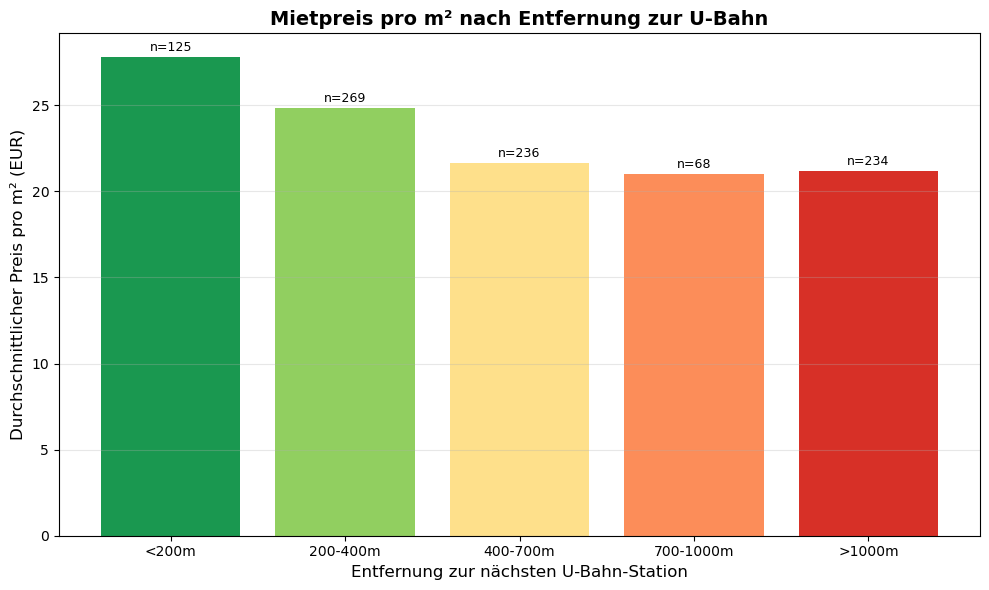

In [14]:
# 8.1 Balkendiagramm: Durchschnittlicher Preis/m² nach Entfernungsband (MapReduce-Ergebnis)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#1a9850", "#91cf60", "#fee08b", "#fc8d59", "#d73027"]
bars = ax.bar(mr_results["distance_band"].astype(str), mr_results["avg_price_per_m2"], color=colors)

for bar, count in zip(bars, mr_results["count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"n={count}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Entfernung zur nächsten U-Bahn-Station", fontsize=12)
ax.set_ylabel("Durchschnittlicher Preis pro m² (EUR)", fontsize=12)
ax.set_title("Mietpreis pro m² nach Entfernung zur U-Bahn", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

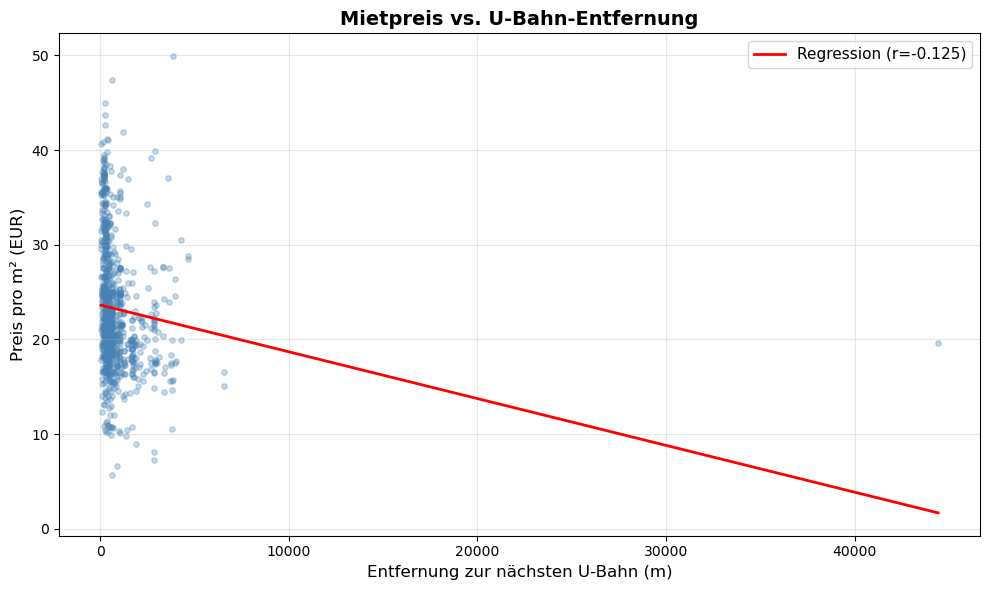

In [15]:
# 8.2 Scatter-Plot: Entfernung vs. Preis/m² mit Regressionslinie
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["dist_to_ubahn_m"], df["price_per_m2"], alpha=0.3, s=15, color="steelblue")

# Regressionslinie
z = np.polyfit(df["dist_to_ubahn_m"], df["price_per_m2"], 1)
p_line = np.poly1d(z)
x_line = np.linspace(df["dist_to_ubahn_m"].min(), df["dist_to_ubahn_m"].max(), 100)
ax.plot(x_line, p_line(x_line), "r-", linewidth=2, label=f"Regression (r={pearson_r:.3f})")

ax.set_xlabel("Entfernung zur nächsten U-Bahn (m)", fontsize=12)
ax.set_ylabel("Preis pro m² (EUR)", fontsize=12)
ax.set_title("Mietpreis vs. U-Bahn-Entfernung", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

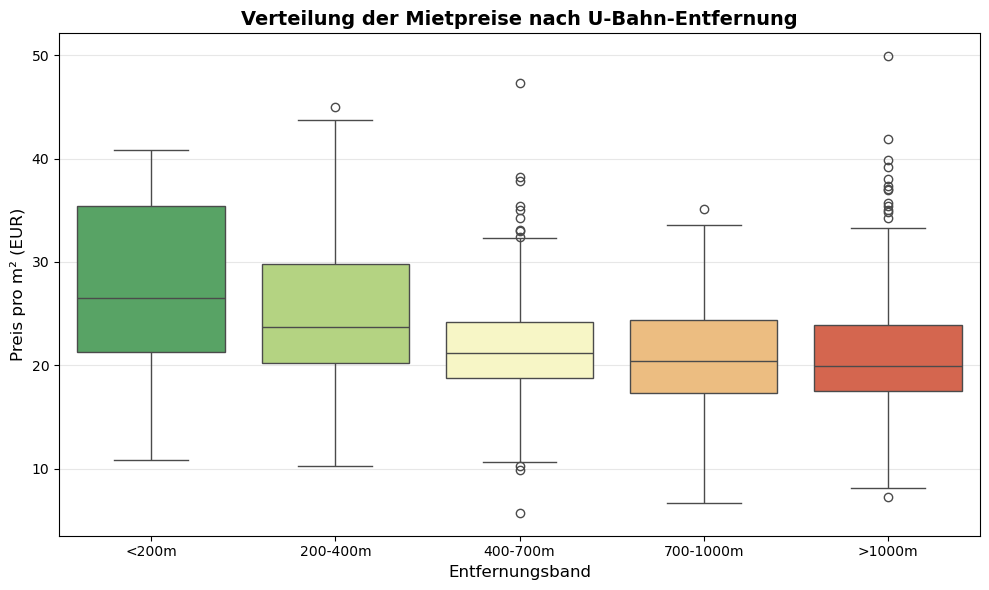

In [16]:
# 8.3 Box-Plot: Preisverteilung pro Entfernungsband
fig, ax = plt.subplots(figsize=(10, 6))
df_plot = df.copy()
df_plot["distance_band"] = pd.Categorical(df_plot["distance_band"], categories=band_order, ordered=True)

sns.boxplot(data=df_plot, x="distance_band", y="price_per_m2", ax=ax, hue="distance_band", palette="RdYlGn_r", legend=False)
ax.set_xlabel("Entfernungsband", fontsize=12)
ax.set_ylabel("Preis pro m² (EUR)", fontsize=12)
ax.set_title("Verteilung der Mietpreise nach U-Bahn-Entfernung", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

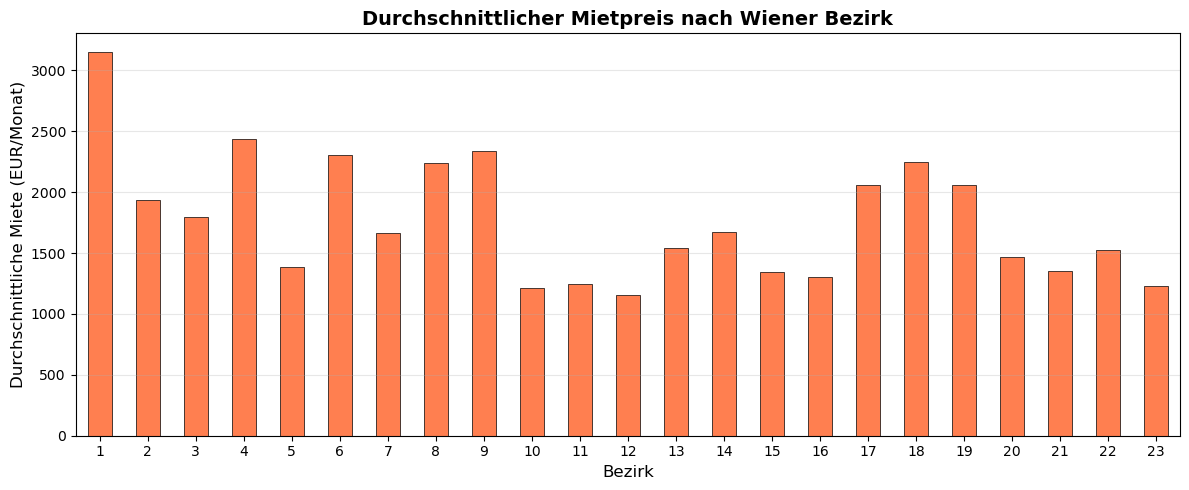

In [17]:
# 8.4 Durchschnittlicher Mietpreis pro Bezirk
district_prices = df.groupby("district")["price"].mean().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
district_prices.plot(kind="bar", ax=ax, color="coral", edgecolor="black", linewidth=0.5)
ax.set_xlabel("Bezirk", fontsize=12)
ax.set_ylabel("Durchschnittliche Miete (EUR/Monat)", fontsize=12)
ax.set_title("Durchschnittlicher Mietpreis nach Wiener Bezirk", fontsize=14, fontweight="bold")
ax.set_xticklabels([f"{int(x)}" for x in district_prices.index], rotation=0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# 8.5 Interaktive Karte: Mietpreis-Heatmap + U-Bahn-Stationen
import folium
from folium.plugins import HeatMap

# Wien-Mittelpunkt
vienna_center = [48.2082, 16.3738]
m = folium.Map(location=vienna_center, zoom_start=12, tiles="cartodbpositron")

# U-Bahn-Stationen als Marker
line_colors = {"U1": "red", "U2": "purple", "U3": "orange", "U4": "green", "U6": "brown"}
for _, station in df_stations.iterrows():
    main_line = station["lines"][0] if station["lines"] else "U1"
    color = line_colors.get(main_line, "blue")
    folium.CircleMarker(
        location=[station["latitude"], station["longitude"]],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.9,
        popup=f"<b>{station['station_name']}</b><br>Linien: {', '.join(station['lines'])}"
    ).add_to(m)

# Mietpreis-Heatmap (gewichtet nach Preis/m²)
heat_data = df[["latitude", "longitude", "price_per_m2"]].dropna().values.tolist()
HeatMap(heat_data, radius=15, blur=10, max_zoom=13, name="Mietpreis-Heatmap").add_to(m)

# Legende
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:10px; border-radius:5px; border:1px solid grey; font-size:12px;">
<b>Legende</b><br>
<span style="color:red;">&#9679;</span> U1 &nbsp;
<span style="color:purple;">&#9679;</span> U2 &nbsp;
<span style="color:orange;">&#9679;</span> U3 &nbsp;
<span style="color:green;">&#9679;</span> U4 &nbsp;
<span style="color:brown;">&#9679;</span> U6<br>
<span style="background:linear-gradient(90deg, blue, lime, yellow, red); display:inline-block; width:100px; height:10px;"></span> Preis/m²
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl().add_to(m)
m

---
# 9. Big-Data-Einordnung

Unser Datensatz ist mit Stand 18.04.2026 ca. 5300 Inseraten und 98 Stationen absolut kein klassischer Big-Data-Anwendungsfall. Dennoch lässt sich das Projekt anhand der Big-Data-Kriterien einordnen und theoretisch skalieren.

## 9.1 Die 5 V's

|  | BigData Projekt |
|---|---|
| **Volume** | Kleiner Datensatz | 
| **Velocity** | "Immediate processing of generated data" --> Scraper läuft bei jedem Push (~siehe Commit-Historie), daher niedrige Geschwindigkeit | 
| **Variety** | semi-strukturierte Quelle mit Willhaben-JSON (variable Felder pro Inserat) + strukturierte Quelle mit Wiener-Linien-CSV | 
| **Veracity** | es findet eine Datenbereinigung statt, die Auswirkungen auf andere V's sind allerdings sehr gering (dem Gesamtnaturell des Projekts geschuldet) | 
| **Value** | beantwortet eine konkrete Frage, möglicherweise nützlich für Investoren, Wohnungssuchende,... | 

## 9.2 Die 4 Ebenen der Datenverarbeitung

| Ebene | Umsetzung im Projekt |
|---|---|
| **Data Source** | Willhaben (Web Scraping mit BeautifulSoup von JSON-Daten) und Wiener Linien Open Data (3 CSV-Dateien), automatisiert durch Python-Skripte in Docker |
| **Data Storage** | MongoDB mit GeoJSON-Feldern, persistente Speicherung auf Azure VM, Daten über Mongo Express und pymongo zugänglich |
| **Data Analysis** | Pandas für Datenbereinigung und explorative Analyse, MapReduce-Pattern (Python + MongoDB Aggregation) für durchschnittlichen Preis/m² nach Entfernungskategorie, Haversine-Formel für Entfernungsberechnungen |
| **Data Output** | Jupyter Notebook als Bericht, Matplotlib/Seaborn für statistische Diagramme, Folium für interaktive Karte mit Heatmap, Ergebnisse direkt im Notebook sichtbar und über die Azure VM abrufbar |

---
# 10. Fazit

Bzgl. des Ergebnis und der Beantwortung der Forschungfrage ist eine interaktive Antwort in Abschnitt 7.